In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = "APMS23-24-Posttraumatic-Stress-Disorder-data-tables.xlsx"

In [4]:
workbook = pd.ExcelFile(file_path)

### Table 3.5 Employment Table 

In [6]:
employment_table = pd.read_excel(
    file_path,
    sheet_name="Table 3.4",
    header=None
)

Algorithm note - Importing the employment table from Excel

We use `pd.read_excel()` to load the original NHS employment table into a pandas DataFrame.

`file_path` specifies the location of the Excel workbook.
`sheet_name="Table 3.4"` selects the employment worksheet.
`header=None` prevents pandas from treating the first row as column names because the NHS table contains titles and multiple header rows.

Result: `employment_table` contains the raw NHS employment worksheet, including its headings, percentages, sample sizes, and footnotes.

The employment data is ready for inspection and cleaning.

In [7]:
employment_table.head(20)

,0,1,2,3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,Table 3.4: Screening positive for probable PTS...,NaN,NaN,NaN
4,All adults aged 16 to 64,NaN,NaN,NaN
5,Trauma1 \nScreen p...,Employment status3,NaN,NaN
6,NaN,Employed,Unemployed,Economically inactive
7,NaN,%,%,%
8,Age-standardised4,NaN,NaN,NaN
9,Men,NaN,NaN,NaN


In [ ]:
# Inspect the rows that contain the main employment/PTSD percentage estimates

employment_table.iloc[10:20]

,0,1,2,3
10,Trauma experienced,30.2966,37.192879,38.259944
11,PTSD screen positive,4.677694,21.948321,14.213685
12,NaN,NaN,NaN,NaN
13,Women,NaN,NaN,NaN
14,Trauma experienced,34.911678,[21.7],43.638127
15,PTSD screen positive,4.791467,[16.7],14.880567
16,NaN,NaN,NaN,NaN
17,All adults5,NaN,NaN,NaN
18,Trauma experienced,32.738982,31.186847,41.513116
19,PTSD screen positive,4.72481,19.89263,15.104183


Algorithm note - Inspecting rows with .iloc

`employment_table.iloc[10:20]`

We inspect rows 10 to 19 to understand how the original NHS employment data is organised.
`.iloc` selects rows by numerical position. Python includes row 10 but excludes row 20.

We can see trauma and PTSD percentage estimates, gender headings (Women, All adults5), and blank rows (NaN).
Column 0 contains group labels and measures. Columns 1–3 contain employment-related percentage estimates.
Some values are in brackets, such as [21.7], so we need to preserve and investigate these flags during cleaning.

Why? We must identify the correct data rows, gender groups and unusual values before extracting and cleaning the dataset.
This code only displays the rows; it does not change the original data.

In [9]:
# Select the main estimate rows and the first four columns
# Rows 10 to 19 contain the percentage section we are inspecting
# Columns 0 to 3 contain the measure/group labels and employment categories

employment_table.iloc[10:20, 0:4]

,0,1,2,3
10,Trauma experienced,30.2966,37.192879,38.259944
11,PTSD screen positive,4.677694,21.948321,14.213685
12,NaN,NaN,NaN,NaN
13,Women,NaN,NaN,NaN
14,Trauma experienced,34.911678,[21.7],43.638127
15,PTSD screen positive,4.791467,[16.7],14.880567
16,NaN,NaN,NaN,NaN
17,All adults5,NaN,NaN,NaN
18,Trauma experienced,32.738982,31.186847,41.513116
19,PTSD screen positive,4.72481,19.89263,15.104183


Algorithm note - Inspecting the employment percentage section

We use `.iloc[10:20, 0:4]` to inspect a specific section of the original NHS employment table.

- `.iloc[]` selects data by numerical row and column positions.
- `10:20` selects rows 10–19 (20 excluded).
- `0:4` selects columns 0–3 (4 excluded).

Observations:
- Rows 10–11: Men's trauma and PTSD estimates.
- Rows 12 and 16: Empty separator rows (`NaN`).
- Rows 13 and 17: Women and All adults group labels.
- Rows 14–15: Women's estimates.
- Rows 18–19: All adults' estimates.
- Values in `[ ]`: NHS-flagged estimates requiring caution.

Why? To identify the structure, group labels, missing rows, and flagged values before cleaning.

Result: We understand which rows contain useful observations and which rows are headings or separators.

In [10]:
# Extract the section containing gender labels and percentage observations
# .copy() creates a separate DataFrame that we can safely clean
employment_estimates = employment_table.iloc[9:20, 0:4].copy()

# Display the extracted section
employment_estimates

,0,1,2,3
9,Men,NaN,NaN,NaN
10,Trauma experienced,30.2966,37.192879,38.259944
11,PTSD screen positive,4.677694,21.948321,14.213685
12,NaN,NaN,NaN,NaN
13,Women,NaN,NaN,NaN
14,Trauma experienced,34.911678,[21.7],43.638127
15,PTSD screen positive,4.791467,[16.7],14.880567
16,NaN,NaN,NaN,NaN
17,All adults5,NaN,NaN,NaN
18,Trauma experienced,32.738982,31.186847,41.513116


Algorithm note - Extracting employment estimates

We use `.iloc[9:20, 0:4].copy()` to extract the percentage section into a separate DataFrame.

- `employment_table` = original NHS table.
- `.iloc[9:20, 0:4]` = selects rows 9–19 and columns 0–3.
- `.copy()` = creates an independent copy so cleaning does not modify the original table.
- `employment_estimates` = stores the extracted data.

Observations:
- 11 rows and 4 columns.
- Includes Men, Women, and All adults.
- Contains trauma and PTSD percentage estimates.
- Includes empty rows and NHS-flagged values.

Why? To isolate the relevant data before cleaning without changing the original NHS dataset.

Result: `employment_estimates` contains the section needed for further cleaning.

In [11]:
# Display column 0 to examine the gender labels and measure names
employment_estimates.iloc[:, 0]

9                      Men
10      Trauma experienced
11    PTSD screen positive
12                     NaN
13                   Women
14      Trauma experienced
15    PTSD screen positive
16                     NaN
17             All adults5
18      Trauma experienced
19    PTSD screen positive
Name: 0, dtype: object

Algorithm note - Inspecting column 0

`employment_estimates.iloc[:, 0]`

We inspect the first column because it contains gender headings and trauma/PTSD measure names.

`:` selects all rows, while `0` selects the first column.

We can see three groups: Men (row 9), Women (row 13), and All adults5 (row 17).
Each gender heading is followed by two measures: Trauma experienced and PTSD screen positive. Blank rows (NaN) separate the groups.

The observation rows do not repeat their gender, so Python cannot directly identify which gender each observation belongs to.
Why? We need to understand this structure before using a loop to carry each gender label forward into its observation rows.

This code only inspects the data; it does not modify anything.

In [12]:
# Create an empty list to store the gender for each observation
gender_labels = []

# Start with no gender because we have not read a gender label yet
current_gender = None

In [13]:
# Read each value from column 0 one by one
for value in employment_estimates.iloc[:, 0]:

    # If the value is a gender/group label, remember it
    if value in ["Men", "Women", "All adults5"]:
        current_gender = value

    # Display the current value and check the gender Python is remembering
    print(value, "->", current_gender)

    # Store the remembered gender
    gender_labels.append(current_gender)

Men -> Men
Trauma experienced -> Men
PTSD screen positive -> Men
nan -> Men
Women -> Women
Trauma experienced -> Women
PTSD screen positive -> Women
nan -> Women
All adults5 -> All adults5
Trauma experienced -> All adults5
PTSD screen positive -> All adults5


Algorithm note (Gender Tracking)

Our NHS table contains gender headings (Men, Women, All adults), but the observation rows do not repeat their gender.
We loop through column 0 because it contains both gender headings and PTSD/trauma observations.
When Python finds a gender heading, it remembers that gender in `current_gender`.
For the following observation rows, Python keeps the same gender until it encounters a new heading.
Each remembered gender is added to `gender_labels`, building a list that matches the rows.
We then create a new `gender` column so every observation has its own gender information.
Why? We need to preserve gender before removing the original headings. This allows us to compare PTSD screening between men, women and all adults later.



In [14]:
# Display the stored gender labels
gender_labels

['Men',
 'Men',
 'Men',
 'Men',
 'Women',
 'Women',
 'Women',
 'Women',
 'All adults5',
 'All adults5',
 'All adults5']

In [15]:
# Add the stored gender labels as a new column
employment_estimates["gender"] = gender_labels

# Display the updated DataFrame
employment_estimates

,0,1,2,3,gender
9,Men,NaN,NaN,NaN,Men
10,Trauma experienced,30.2966,37.192879,38.259944,Men
11,PTSD screen positive,4.677694,21.948321,14.213685,Men
12,NaN,NaN,NaN,NaN,Men
13,Women,NaN,NaN,NaN,Women
14,Trauma experienced,34.911678,[21.7],43.638127,Women
15,PTSD screen positive,4.791467,[16.7],14.880567,Women
16,NaN,NaN,NaN,NaN,Women
17,All adults5,NaN,NaN,NaN,All adults5
18,Trauma experienced,32.738982,31.186847,41.513116,All adults5


Algorithm note - Adding the gender column

`employment_estimates["gender"] = gender_labels`

Previously, we used a loop to remember the gender for every row and stored those labels in `gender_labels`.
Now we add that list to our DataFrame as a new column called `gender`.

Python assigns each stored gender to its corresponding row. For example, rows 9–12 are Men, rows 13–16 are Women, and rows 17–19 are All adults5.

Even blank rows receive a gender because the loop recorded a label for every row.

Why? The original NHS table only shows gender as a heading. We need each trauma/PTSD observation to have its own gender so we can safely remove headings and blank rows later.

Result: The original percentage values remain unchanged, but every row now has an identifiable gender.

In [16]:
# Define the measures that represent actual observations
observation_measures = [
    "Trauma experienced",
    "PTSD screen positive"
]

# Keep only rows where column 0 contains one of the observation measures
employment_estimates = employment_estimates[
    employment_estimates[0].isin(observation_measures)
].copy()

# Display the cleaned result
employment_estimates

,0,1,2,3,gender
10,Trauma experienced,30.2966,37.192879,38.259944,Men
11,PTSD screen positive,4.677694,21.948321,14.213685,Men
14,Trauma experienced,34.911678,[21.7],43.638127,Women
15,PTSD screen positive,4.791467,[16.7],14.880567,Women
18,Trauma experienced,32.738982,31.186847,41.513116,All adults5
19,PTSD screen positive,4.72481,19.89263,15.104183,All adults5


Algorithm note - Filtering observations

Our extracted NHS table still contains gender headings and blank rows, which are not actual observations.
We use .isin() to identify rows containing Trauma experienced or PTSD screen positive.
Python keeps only the rows matching these two measures and removes the other rows.
The gender column stays because we created it before filtering.
Why? We want a clean dataset containing only useful percentage observations, ready for renaming, reshaping and analysis.

In [17]:
# Rename the numbered columns using their actual meanings from the NHS table
employment_estimates = employment_estimates.rename(
    columns={
        0: "measure",
        1: "Employed",
        2: "Unemployed",
        3: "Economically inactive"
    }
)

# Display the DataFrame to check the new column names
employment_estimates

,measure,Employed,Unemployed,Economically inactive,gender
10,Trauma experienced,30.2966,37.192879,38.259944,Men
11,PTSD screen positive,4.677694,21.948321,14.213685,Men
14,Trauma experienced,34.911678,[21.7],43.638127,Women
15,PTSD screen positive,4.791467,[16.7],14.880567,Women
18,Trauma experienced,32.738982,31.186847,41.513116,All adults5
19,PTSD screen positive,4.72481,19.89263,15.104183,All adults5


 Algorithm note - Renaming columns 

After filtering, our NHS data still has numbered columns (0, 1, 2, 3), which do not explain what the values represent.

We use `.rename(columns={...})` to replace these numbers with meaningful names: measure, Employed, Unemployed and Economically inactive.

The dictionary maps each old column name to its new name.
The data values and gender column remain unchanged.
Why? We need clear column names so we can identify employment categories and reshape the data from wide to long format for analysis.

In [18]:
# Reshape the table from wide format to long format
# This creates one row for each gender, measure, and employment status combination
employment_long = employment_estimates.melt(
    id_vars=["gender", "measure"],
    value_vars=["Employed", "Unemployed", "Economically inactive"],
    var_name="employment_status",
    value_name="percentage"
)

# Display the reshaped table
employment_long

,gender,measure,employment_status,percentage
0,Men,Trauma experienced,Employed,30.2966
1,Men,PTSD screen positive,Employed,4.677694
2,Women,Trauma experienced,Employed,34.911678
3,Women,PTSD screen positive,Employed,4.791467
4,All adults5,Trauma experienced,Employed,32.738982
5,All adults5,PTSD screen positive,Employed,4.72481
6,Men,Trauma experienced,Unemployed,37.192879
7,Men,PTSD screen positive,Unemployed,21.948321
8,Women,Trauma experienced,Unemployed,[21.7]
9,Women,PTSD screen positive,Unemployed,[16.7]


Algorithm note - Wide to long transformation

`employment_long = employment_estimates.melt(...)`

Our NHS data has three employment categories stored in separate columns, making comparisons and further processing less convenient.

We use `.melt()` to reorganise these columns into rows.
`id_vars` keeps gender and measure attached to each observation.
`value_vars` selects the three employment columns to reshape.
`var_name` creates one employment_status column containing Employed, Unemployed and Economically inactive.
`value_name` creates one percentage column containing their corresponding estimates.

Why? We need a consistent dataset where each row represents one gender, one measure and one employment status. This makes grouping, merging, visualisation and statistical analysis easier.

Result: 6 rows become 18 rows, with 4 columns. The percentage values remain unchanged.

In [19]:
# Check the data type of each column before cleaning the percentage values
employment_long.dtypes

gender               object
measure              object
employment_status    object
percentage           object
dtype: object

In [20]:
# Create a new column that checks whether the percentage value is enclosed in brackets
employment_long["is_flagged"] = (
    employment_long["percentage"]
    .astype(str)
    .str.startswith("[")
)

# Display the percentage and flag columns
employment_long[["percentage", "is_flagged"]]

,percentage,is_flagged
0,30.2966,False
1,4.677694,False
2,34.911678,False
3,4.791467,False
4,32.738982,False
5,4.72481,False
6,37.192879,False
7,21.948321,False
8,[21.7],True
9,[16.7],True


Algorithm note - Identifying flagged percentages

Some NHS percentage estimates appear in square brackets, such as [21.7], indicating that they need special caution.

We convert the percentage values to strings so Python can check whether each value starts with `[`. The result is stored in a new `is_flagged` column as True or False.

Why? We need to preserve which estimates were flagged before removing the brackets and converting percentages into numbers.

Result: Every observation now has a flag showing whether its original percentage was bracketed. The original percentage values remain unchanged.

In [21]:
# Remove square brackets from flagged percentage values
employment_long["percentage"] = (
    employment_long["percentage"]
    .astype(str)
    .str.strip("[]")
)

# Convert the cleaned percentage values from text to numeric values
employment_long["percentage"] = pd.to_numeric(
    employment_long["percentage"]
)

# Check the percentage values and their data type
employment_long[["percentage", "is_flagged"]]

,percentage,is_flagged
0,30.296600,False
1,4.677694,False
2,34.911678,False
3,4.791467,False
4,32.738982,False
5,4.724810,False
6,37.192879,False
7,21.948321,False
8,21.700000,True
9,16.700000,True


Algorithm note  - Cleaning percentage values

Some NHS percentages contain square brackets, such as [21.7], so pandas may treat them as text rather than numbers.

We use `.astype(str)` to convert all percentage values into strings, then `.str.strip("[]")` to remove the brackets.
Next, `pd.to_numeric()` converts the cleaned values into numbers so Python can perform calculations and create charts.

Why? Statistical analysis requires numeric percentages. We have already preserved the original NHS warning information in `is_flagged`, so removing the brackets does not lose that information.

Result: The percentage column contains numeric values, while `is_flagged` still identifies estimates requiring caution.

In [23]:
# Display the structure and data types of the cleaned percentage dataset
employment_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             18 non-null     object 
 1   measure            18 non-null     object 
 2   employment_status  18 non-null     object 
 3   percentage         18 non-null     float64
 4   is_flagged         18 non-null     bool   
dtypes: bool(1), float64(1), object(3)
memory usage: 726.0+ bytes


Algorithm note - Checking the cleaned dataset structure

employment_long.info()

After cleaning and reshaping the NHS employment data, we inspect the DataFrame's structure to confirm that the cleaning process worked correctly.
We use .info() to check the number of rows, columns, missing values, data types and memory usage.

The dataset contains 18 rows and 5 columns. All columns have 18 non-null values, meaning no missing values are detected.

In [24]:
# Validate the cleaned data by selecting one known observation
validation_check = employment_long[
    (employment_long["gender"] == "Men")
    & (employment_long["measure"] == "PTSD screen positive")
    & (employment_long["employment_status"] == "Unemployed")
]

# Display the result for comparison with the original Excel table
validation_check

,gender,measure,employment_status,percentage,is_flagged
7,Men,PTSD screen positive,Unemployed,21.948321,False


Algorithm note - Validating a cleaned observation

`validation_check = employment_long[...]`

After cleaning the NHS employment data, we select one known observation to check whether the original information has been preserved correctly.

We use `==` to check three conditions: gender is Men, measure is PTSD screen positive, and employment_status is Unemployed.
The `&` operator combines these conditions, meaning all three must be True for a row to be selected.
Python filters the DataFrame and returns the matching observation, showing a percentage of 21.948321 and `is_flagged = False`.

Why? Cleaning and reshaping can accidentally change values or assign them to incorrect categories. We need to compare the cleaned observation against the original NHS Excel table to verify its accuracy.


In [25]:
# Validate a value that was originally shown in square brackets
validation_flagged = employment_long[
    (employment_long["gender"] == "Women")
    & (employment_long["measure"] == "PTSD screen positive")
    & (employment_long["employment_status"] == "Unemployed")
]

# Display the cleaned percentage and its preserved statistical flag
validation_flagged

,gender,measure,employment_status,percentage,is_flagged
9,Women,PTSD screen positive,Unemployed,16.7,True


Algorithm note - Validating a flagged NHS estimate

`validation_flagged = employment_long[...]`

After cleaning the percentages, we check whether the original NHS statistical flags have been preserved correctly.

We use `==` and `&` to select an observation where gender is Women, measure is PTSD screen positive, and employment_status is Unemployed.
Python returns a percentage of 16.7 with `is_flagged = True`.
Originally, this percentage appeared as `[16.7]` in the NHS Excel table. We removed the brackets to convert it into a numeric value but stored the warning information separately.

Why? Bracketed estimates require caution when interpreting results. We must ensure that cleaning the data does not accidentally remove important information about estimate reliability.


In [26]:
# Extract the unweighted sample base rows from the original Table 3.4
# Rows 22 to 24 contain the gender groups and their sample counts
# Columns 0 to 3 contain gender and the three employment categories
unweighted_bases = employment_table.iloc[22:25, 0:4].copy()

# Display the extracted unweighted base table
unweighted_bases

,0,1,2,3
22,Men,1203.0,50,352.0
23,Women,1719.0,44,649
24,All adults5,2925,94.0,1007.0


Algorithm note - Extracting unweighted sample bases

`unweighted_bases = employment_table.iloc[22:25, 0:4].copy()`

After cleaning the PTSD percentage estimates, we return to the original NHS Excel table to extract the unweighted sample bases.
Unweighted bases represent the actual number of survey respondents in each gender and employment group, before survey weighting.

We use `.iloc[22:25, 0:4]` to select rows 22–24 and columns 0–3, which contain gender labels and sample counts for Employed, Unemployed and Economically inactive respondents.
`.copy()` creates an independent DataFrame so we can clean and reshape these counts without modifying the original worksheet.

The extracted data shows, for example, 50 unemployed men and 44 unemployed women, giving 94 unemployed adults in the combined group.

Why? Percentages alone do not tell us how many respondents contributed to an estimate. We need sample counts to assess reliability, identify small groups and support appropriate statistical analysis.

Result: We create `unweighted_bases`, containing three gender groups and their respondent counts across three employment categories.

In [27]:
# Rename the columns so each column clearly describes what it contains
unweighted_bases = unweighted_bases.rename(
    columns={
        0: "gender",
        1: "Employed",
        2: "Unemployed",
        3: "Economically inactive"
    }
)

# Display the renamed unweighted base table
unweighted_bases

,gender,Employed,Unemployed,Economically inactive
22,Men,1203.0,50,352.0
23,Women,1719.0,44,649
24,All adults5,2925,94.0,1007.0


Algorithm note - Renaming unweighted sample base columns

`unweighted_bases = unweighted_bases.rename(...)`

After extracting the unweighted sample counts, our NHS table still contains numbered columns (0, 1, 2, 3), which do not clearly describe the data.
We use `.rename(columns={...})` to replace these numbers with meaningful names: gender, Employed, Unemployed and Economically inactive.
The dictionary maps each original column number to its corresponding category. We assign the renamed DataFrame back to `unweighted_bases`.

In [28]:
# Reshape the unweighted base table from wide format to long format
unweighted_long = unweighted_bases.melt(
    id_vars=["gender"],
    value_vars=["Employed", "Unemployed", "Economically inactive"],
    var_name="employment_status",
    value_name="sample_size"
)

# Display the reshaped table
unweighted_long

,gender,employment_status,sample_size
0,Men,Employed,1203.0
1,Women,Employed,1719.0
2,All adults5,Employed,2925
3,Men,Unemployed,50
4,Women,Unemployed,44
5,All adults5,Unemployed,94.0
6,Men,Economically inactive,352.0
7,Women,Economically inactive,649
8,All adults5,Economically inactive,1007.0


Algorithm note - Reshaping unweighted sample bases

`unweighted_long = unweighted_bases.melt(...)`

Our NHS unweighted sample counts are currently stored in wide format, with Employed, Unemployed and Economically inactive as separate columns.
We use `.melt()` to transform these employment columns into rows while keeping the original sample counts unchanged.
`id_vars=["gender"]` preserves the gender associated with each sample count.
`value_vars` selects the three employment categories that need to be reshaped.
`var_name="employment_status"` creates one column containing the employment categories, while `value_name="sample_size"` creates another column containing their respondent counts.

Why? Our cleaned PTSD percentage dataset is already in long format. We need the unweighted sample counts in a matching structure so we can merge them using gender and employment status.

In [29]:
# Remove the footnote number from the "All adults" group label
unweighted_long["gender"] = unweighted_long["gender"].replace(
    "All adults5",
    "All adults"
)

# Convert sample size values to numeric data
unweighted_long["sample_size"] = pd.to_numeric(
    unweighted_long["sample_size"]
)

# Display the cleaned unweighted base table
unweighted_long

,gender,employment_status,sample_size
0,Men,Employed,1203.0
1,Women,Employed,1719.0
2,All adults,Employed,2925.0
3,Men,Unemployed,50.0
4,Women,Unemployed,44.0
5,All adults,Unemployed,94.0
6,Men,Economically inactive,352.0
7,Women,Economically inactive,649.0
8,All adults,Economically inactive,1007.0


Algorithm note - Cleaning unweighted sample bases

`unweighted_long["gender"].replace(...)`

After reshaping the unweighted sample counts, we clean the gender labels and ensure the sample sizes are stored as numeric values.
We use `.replace()` to change `All adults5` into `All adults`, removing the footnote number from the original NHS label.
Next, `pd.to_numeric()` converts the `sample_size` column into numeric data so Python can perform calculations and comparisons.

The original respondent counts remain unchanged. 

Why? We need consistent gender labels to match the cleaned PTSD percentage dataset when merging. We also need numeric sample sizes to assess estimate reliability and identify groups with small respondent counts.

Result: `unweighted_long` contains 9 rows and 3 columns: gender, employment_status and sample_size. The gender labels are standardised, and sample counts are numeric, ready for validation and merging.

In [30]:
# Extract the weighted base section from the original Table 3.4
# Rows 27 to 29 contain Men, Women, and All adults
# Columns 0 to 3 contain gender and the three employment categories
weighted_bases = employment_table.iloc[27:30, 0:4].copy()

# Rename the weighted base columns using their actual meanings
weighted_bases = weighted_bases.rename(
    columns={
        0: "gender",
        1: "Employed",
        2: "Unemployed",
        3: "Economically inactive"
    }
)

# Display the extracted weighted base table
weighted_bases

,gender,Employed,Unemployed,Economically inactive
27,Men,1393.26242,55.580259,391.417546
28,Women,1375.471907,35.565041,479.966205
29,All adults5,2774.245548,91.145299,878.789867


Algorithm note - Extracting and renaming weighted sample bases

`weighted_bases = employment_table.iloc[27:30, 0:4].copy()`

After preparing the unweighted sample counts, we return to the original NHS table to extract the weighted sample bases.
Weighted bases represent survey-adjusted counts that account for the survey's weighting system. Unlike unweighted bases, they are not the actual number of respondents.

We use `.iloc[27:30, 0:4]` to extract rows 27–29 and columns 0–3, containing the three gender groups and their weighted values across employment categories.
`.copy()` creates an independent DataFrame so we can clean and reshape the weighted data without modifying the original table.
Next, `.rename(columns={...})` replaces the numbered columns with meaningful names: gender, Employed, Unemployed and Economically inactive.

Why? We need weighted bases to understand the survey-adjusted population representation and interpret the reported NHS percentages alongside the actual unweighted sample sizes.

Result: `weighted_bases` contains 3 rows and 4 columns, representing weighted values for Men, Women and All adults5 across the three employment categories. The original weighted values remain unchanged, ready for further cleaning and reshaping.

In [31]:
# Reshape the weighted base table from wide format to long format
# Employment categories become values inside one "employment_status" column
weighted_long = weighted_bases.melt(
    id_vars=["gender"],
    value_vars=["Employed", "Unemployed", "Economically inactive"],
    var_name="employment_status",
    value_name="weighted_base"
)

# Display the reshaped weighted base table
weighted_long

,gender,employment_status,weighted_base
0,Men,Employed,1393.26242
1,Women,Employed,1375.471907
2,All adults5,Employed,2774.245548
3,Men,Unemployed,55.580259
4,Women,Unemployed,35.565041
5,All adults5,Unemployed,91.145299
6,Men,Economically inactive,391.417546
7,Women,Economically inactive,479.966205
8,All adults5,Economically inactive,878.789867


Algorithm note - Reshaping weighted sample bases

`weighted_long = weighted_bases.melt(...)`

Same process as reshaping the unweighted sample bases.

We use `.melt()` to convert the three employment columns into rows while preserving gender and the original weighted values.
The main difference is `value_name="weighted_base"` instead of `sample_size`, because these are survey-adjusted values rather than actual respondent counts.

Why? We need the weighted bases in the same long format as our percentage and unweighted datasets so they can be merged using gender and employment status.

In [32]:
# Remove the footnote number from the "All adults" group label
weighted_long["gender"] = weighted_long["gender"].replace(
    "All adults5",
    "All adults"
)

# Check that the gender labels are now consistent
weighted_long["gender"].unique()

array(['Men', 'Women', 'All adults'], dtype=object)

In [33]:
# Check the number of rows, missing values, and data types
weighted_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   gender             9 non-null      object
 1   employment_status  9 non-null      object
 2   weighted_base      9 non-null      object
dtypes: object(3)
memory usage: 348.0+ bytes


In [34]:
# Combine the actual sample counts and NHS weighted bases
employment_bases = unweighted_long.merge(
    weighted_long,
    on=["gender", "employment_status"],
    how="inner"
)

employment_bases

,gender,employment_status,sample_size,weighted_base
0,Men,Employed,1203.0,1393.26242
1,Women,Employed,1719.0,1375.471907
2,All adults,Employed,2925.0,2774.245548
3,Men,Unemployed,50.0,55.580259
4,Women,Unemployed,44.0,35.565041
5,All adults,Unemployed,94.0,91.145299
6,Men,Economically inactive,352.0,391.417546
7,Women,Economically inactive,649.0,479.966205
8,All adults,Economically inactive,1007.0,878.789867


Algorithm note - Merging unweighted and weighted sample bases

`employment_bases = unweighted_long.merge(...)`

After cleaning and reshaping both sample base tables, we combine the actual respondent counts and NHS weighted bases into one dataset.

We use `.merge()` to join `unweighted_long` and `weighted_long` using two matching columns: `gender` and `employment_status`.
`how="inner"` keeps only the gender and employment combinations that exist in both datasets.

For example, unemployed men have an actual sample size of 50 and a weighted base of approximately 55.58.

Why? We need both the actual respondent counts and survey-adjusted bases together to assess sample reliability and interpret the NHS percentage estimates correctly.

Result: `employment_bases` contains 9 rows and 4 columns: gender, employment_status, sample_size and weighted_base. Each employment group now has both its unweighted and weighted sample information, ready to merge with the PTSD percentage dataset.

In [35]:
# Check that the merge matched the correct records
employment_bases[
    (employment_bases["gender"] == "Men")
    & (employment_bases["employment_status"] == "Unemployed")
]

,gender,employment_status,sample_size,weighted_base
3,Men,Unemployed,50.0,55.580259


Algorithm note - Validating merged sample bases

`employment_bases[...]`

After merging the unweighted and weighted sample bases, we check whether the correct records were matched.
We use `==` to select Men and Unemployed, while `&` ensures both conditions are satisfied.

Python returns one matching observation containing an actual sample size of 50 and a weighted base of approximately 55.58.

Why? Merging datasets can produce incorrect matches if the gender or employment labels are inconsistent. We need to verify that the unweighted and weighted values belong to the same group.

#### EDA (Table 3.1 Employment by PTSD)

In [38]:
# Measures by PTSD Screening positive 

ptsd_by_employment = employment_long[
    employment_long["measure"] == "PTSD screen positive"
].copy()

ptsd_by_employment

,gender,measure,employment_status,percentage,is_flagged
1,Men,PTSD screen positive,Employed,4.677694,False
3,Women,PTSD screen positive,Employed,4.791467,False
5,All adults,PTSD screen positive,Employed,4.724810,False
7,Men,PTSD screen positive,Unemployed,21.948321,False
9,Women,PTSD screen positive,Unemployed,16.700000,True
11,All adults,PTSD screen positive,Unemployed,19.892630,False
13,Men,PTSD screen positive,Economically inactive,14.213685,False
15,Women,PTSD screen positive,Economically inactive,14.880567,False
17,All adults,PTSD screen positive,Economically inactive,15.104183,False


Algorithm note - Filtering PTSD screening estimates for EDA

`ptsd_by_employment = employment_long[...]`

After cleaning the employment dataset, we select only the PTSD screening estimates for our first Exploratory Data Analysis (EDA) question.
We use `== "PTSD screen positive"` to filter the `measure` column, keeping only observations related to PTSD screening and excluding trauma-experienced observations.
`.copy()` creates an independent DataFrame so we can analyse the PTSD data without modifying the original cleaned dataset.

In [39]:
# Measures by Trauma Experienced

trauma_by_employment = employment_long[
    employment_long["measure"] == "Trauma experienced"
].copy()

trauma_by_employment

,gender,measure,employment_status,percentage,is_flagged
0,Men,Trauma experienced,Employed,30.296600,False
2,Women,Trauma experienced,Employed,34.911678,False
4,All adults,Trauma experienced,Employed,32.738982,False
6,Men,Trauma experienced,Unemployed,37.192879,False
8,Women,Trauma experienced,Unemployed,21.700000,True
10,All adults,Trauma experienced,Unemployed,31.186847,False
12,Men,Trauma experienced,Economically inactive,38.259944,False
14,Women,Trauma experienced,Economically inactive,43.638127,False
16,All adults,Trauma experienced,Economically inactive,41.513116,False


Algorithm note - Filtering trauma-experienced estimates

`trauma_by_employment = employment_long[...]`

Same filtering process as the PTSD screening dataset, but this time we focus on trauma experience.
We use `== "Trauma experienced"` to keep only trauma-experienced observations and exclude PTSD screening estimates.
`.copy()` creates an independent DataFrame while preserving gender, employment status, percentages and statistical flags.

Why? We want to compare trauma experience across employment groups and genders, and later examine how these patterns differ from PTSD screening results.

In [40]:
# Compare Trauma experienced vs PTSD screen positive
# within each gender and employment status
measure_comparison = employment_long.pivot(
    index=["gender", "employment_status"],
    columns="measure",
    values="percentage"
)

measure_comparison

measure                           PTSD screen positive  Trauma experienced
gender     employment_status                                              
All adults Economically inactive             15.104183           41.513116
           Employed                           4.724810           32.738982
           Unemployed                        19.892630           31.186847
Men        Economically inactive             14.213685           38.259944
           Employed                           4.677694           30.296600
           Unemployed                        21.948321           37.192879
Women      Economically inactive             14.880567           43.638127
           Employed                           4.791467           34.911678
           Unemployed                        16.700000           21.700000

Algorithm note - Comparing trauma experience and PTSD screening

`measure_comparison = employment_long.pivot(...)`

After separating the trauma experience and PTSD screening datasets, we bring both measures together to compare their percentages within each gender and employment group.

We use `.pivot()` to reshape the data from long format into wide format, placing the two measures side by side.`index=["gender", "employment_status"]` groups observations by gender and employment category.
`columns="measure"` creates separate columns for PTSD screen positive and Trauma experienced.
`values="percentage"` fills these columns with their corresponding percentages.

Why? We want to compare trauma experience and PTSD screening within the same population groups and identify differences or patterns across employment categories.

In [41]:
# Keep only the Men's observations
men_data = employment_long[
    employment_long["gender"] == "Men"
].copy()

men_data

,gender,measure,employment_status,percentage,is_flagged
0,Men,Trauma experienced,Employed,30.296600,False
1,Men,PTSD screen positive,Employed,4.677694,False
6,Men,Trauma experienced,Unemployed,37.192879,False
7,Men,PTSD screen positive,Unemployed,21.948321,False
12,Men,Trauma experienced,Economically inactive,38.259944,False
13,Men,PTSD screen positive,Economically inactive,14.213685,False


Algorithm note - Filtering men's employment observations

`men_data = employment_long[...]`

Same filtering process as before, but this time we select only men's observations from the cleaned NHS employment dataset.

We use `employment_long["gender"] == "Men"` to keep rows where the gender is Men, excluding Women and All adults.
`.copy()` creates an independent DataFrame while preserving employment status, measures, percentages and statistical flags.


Result: `men_data` contains 6 rows and 5 columns, representing two measures (Trauma experienced and PTSD screen positive) across three employment categories.

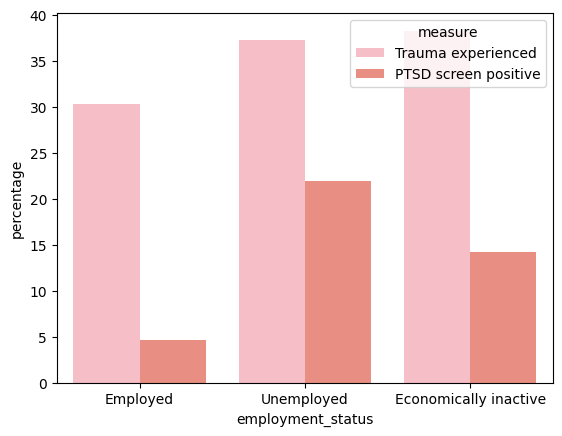

In [42]:
sns.barplot(
    data=men_data,
    x="employment_status",
    y="percentage",
    hue="measure",
    palette=["lightpink", "salmon"]
)

plt.show()

Algorithm note - Visualising trauma experience and PTSD screening among men

`sns.barplot(...)`

After filtering men's observations, we create a grouped bar chart to compare trauma experience and PTSD screening percentages across employment categories.

We use `sns.barplot()` from Seaborn to visualise the data.
`data=men_data` selects the men's dataset.
`x="employment_status"` places the three employment categories on the horizontal axis.
`y="percentage"` determines the height of each bar using the corresponding percentage.
`hue="measure"` separates Trauma experienced and PTSD screen positive into different coloured bars within each employment group.
`palette=["lightpink", "salmon"]` assigns colours to the two measures, while `plt.show()` displays the completed chart.

Result: The chart shows that economically inactive men have the highest trauma-experience percentage (38.26%), while unemployed men have the highest PTSD screening percentage (21.95%). Employed men have the lowest percentages for both measures.

Visualization interpretation - Trauma experience vs PTSD screening among men

The grouped bar chart compares trauma experience and PTSD screening percentages among men across three employment categories: Employed, Unemployed and Economically inactive.

Employed men have the lowest percentages for both trauma experience (30.30%) and PTSD screening positive (4.68%).

Unemployed men have the highest PTSD screening percentage (21.95%), compared with 4.68% among employed men. Their trauma-experience percentage is also relatively high at 37.19%.

Economically inactive men have the highest trauma-experience percentage (38.26%), but their PTSD screening percentage (14.21%) is lower than that of unemployed men.

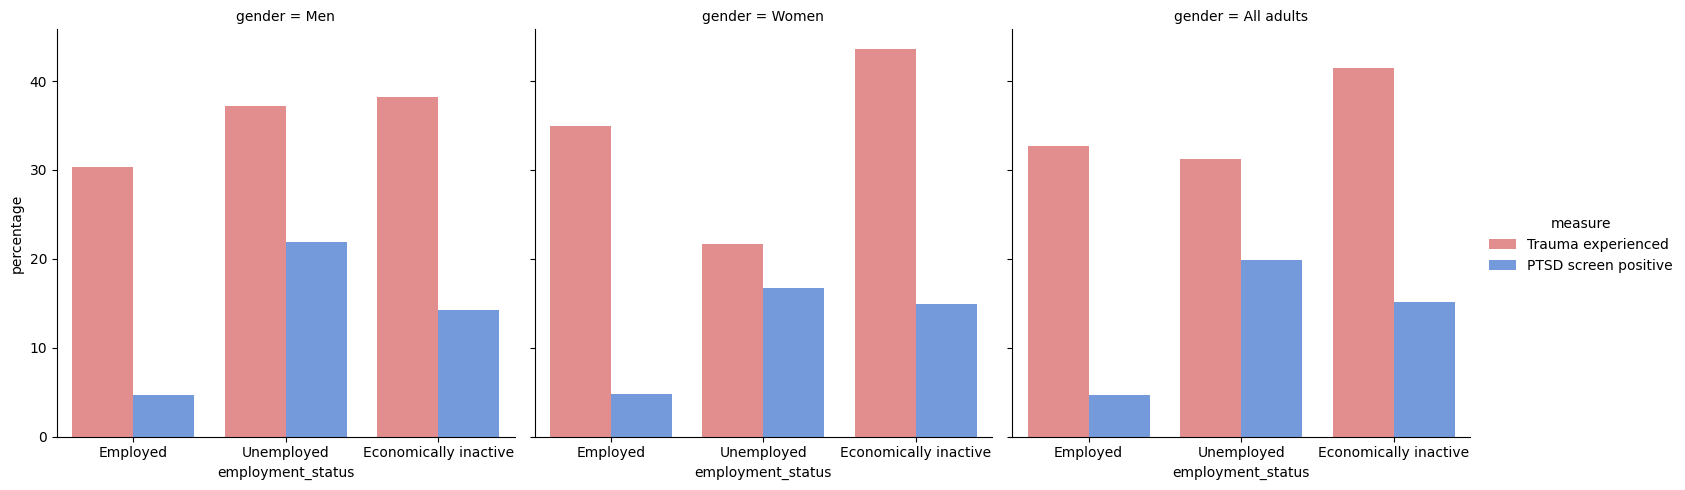

In [43]:
# Compare Trauma and PTSD across employment status
# separately for Men, Women, and All adults
g = sns.catplot(
    data=employment_long,
    x="employment_status",
    y="percentage",
    hue="measure",
    palette=["lightcoral", "cornflowerblue"],
    col="gender",
    kind="bar",
    height=5,
    aspect=1
)

plt.show()

Algorithm note - Comparing trauma and PTSD across gender and employment status

`g = sns.catplot(...)`

After comparing trauma experience and PTSD screening among men, we expand the visualisation to include Men, Women and All adults.

We use `sns.catplot()` to create multiple bar charts from the same NHS employment dataset.
`data=employment_long` selects the cleaned dataset.
`x="employment_status"` places employment categories on the horizontal axis, while `y="percentage"` determines the bar heights.
`hue="measure"` separates Trauma experienced and PTSD screen positive using different colours.
`palette=["lightcoral", "cornflowerblue"]` assigns colours to the two measures.
`col="gender"` creates three separate charts for Men, Women and All adults, allowing us to compare their patterns side by side.
`kind="bar"` specifies bar charts, while `height=5` and `aspect=1` control the size and proportions of each chart.
`plt.show()` displays the completed visualisation.

Visualization interpretation - Trauma and PTSD across gender and employment status

The charts show that employed adults have the lowest PTSD screening percentages across all three gender groups, at approximately 4.7–4.8%.

Among men, unemployed respondents have the highest PTSD screening percentage (21.95%), while economically inactive men have the highest trauma-experience percentage (38.26%).

Among women, economically inactive respondents have the highest trauma-experience percentage (43.64%). Unemployed women have the highest PTSD screening percentage (16.70%), although this estimate is flagged because of the small sample size.

For all adults, unemployed respondents have the highest PTSD screening percentage (19.89%), while economically inactive respondents have the highest trauma-experience percentage (41.51%).

The findings also show that trauma experience and PTSD screening do not follow identical patterns. Higher trauma-experience percentages do not always correspond to higher PTSD screening percentages.


In [44]:
# Within each employment group, how do Men and Women compare?

# Keep only Men and Women for the gender comparison
gender_comparison = employment_long[
    employment_long["gender"].isin(["Men", "Women"])
].copy()

gender_comparison

,gender,measure,employment_status,percentage,is_flagged
0,Men,Trauma experienced,Employed,30.296600,False
1,Men,PTSD screen positive,Employed,4.677694,False
2,Women,Trauma experienced,Employed,34.911678,False
3,Women,PTSD screen positive,Employed,4.791467,False
6,Men,Trauma experienced,Unemployed,37.192879,False
7,Men,PTSD screen positive,Unemployed,21.948321,False
8,Women,Trauma experienced,Unemployed,21.700000,True
9,Women,PTSD screen positive,Unemployed,16.700000,True
12,Men,Trauma experienced,Economically inactive,38.259944,False
13,Men,PTSD screen positive,Economically inactive,14.213685,False


Algorithm note - Filtering gender groups for comparison

We use `.isin(["Men", "Women"])` to select only observations belonging to Men and Women from `employment_long`. Unlike `==`, which checks one value, `.isin()` checks whether each value belongs to a list of accepted categories.

In [45]:
# Keep only PTSD screening estimates
ptsd_gender_comparison = gender_comparison[
    gender_comparison["measure"] == "PTSD screen positive"
].copy()

ptsd_gender_comparison

,gender,measure,employment_status,percentage,is_flagged
1,Men,PTSD screen positive,Employed,4.677694,False
3,Women,PTSD screen positive,Employed,4.791467,False
7,Men,PTSD screen positive,Unemployed,21.948321,False
9,Women,PTSD screen positive,Unemployed,16.700000,True
13,Men,PTSD screen positive,Economically inactive,14.213685,False
15,Women,PTSD screen positive,Economically inactive,14.880567,False


Algorithm note - Filtering PTSD screening estimates for gender comparison

`ptsd_gender_comparison = gender_comparison[...]`

After selecting men's and women's observations, we focus only on PTSD screening estimates to compare both genders within each employment category.

We use `gender_comparison["measure"] == "PTSD screen positive"` to keep PTSD screening observations and exclude trauma-experienced observations.
`.copy()` creates an independent DataFrame while preserving gender, employment status, percentages and statistical flags.

Why? We want to compare PTSD screening percentages between men and women within the same employment groups, without including the All adults category or mixing different measures.

Result: `ptsd_gender_comparison` contains 6 rows and 5 columns, representing Men and Women across three employment categories.

The data shows that unemployed men have a higher PTSD screening percentage (21.95%) than unemployed women (16.70%), although the women's estimate is flagged and requires caution. 
The dataset is ready for gender-specific EDA and visualisation.

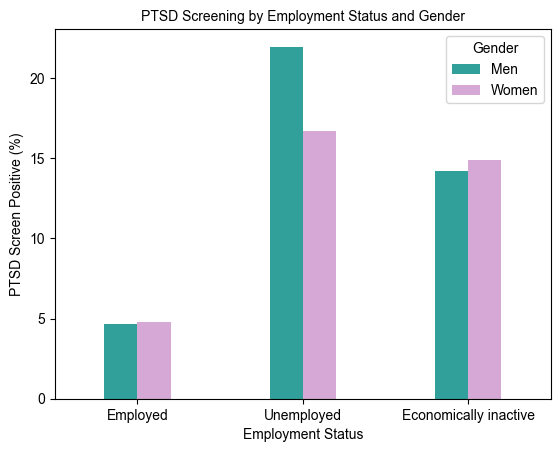

In [46]:
# Visualize Men vs Women

# Set font style for the whole chart
plt.rcParams["font.family"] = "Arial"

sns.barplot(
    data=ptsd_gender_comparison,
    x="employment_status",
    y="percentage",
    hue="gender",
    palette=["lightseagreen", "plum"],
    width=0.4
)

plt.title(
    "PTSD Screening by Employment Status and Gender", 
    fontsize= 10
)

plt.xlabel("Employment Status")
plt.ylabel("PTSD Screen Positive (%)")
plt.legend(title="Gender")

plt.show()

Algorithm note - Visualizing PTSD screening by gender

We use `sns.barplot()` to compare PTSD screening percentages between Men and Women across three employment categories.

`data` selects the filtered PTSD dataset, `x` represents employment status, `y` represents percentages, and `hue="gender"` creates separate bars for Men and Women.

`palette` assigns different colours, while `width=0.4` makes the bars narrower.
`plt.rcParams["font.family"]` sets the chart font. `plt.title()`, `plt.xlabel()`, `plt.ylabel()`, and `plt.legend()` improve readability.
`plt.show()` displays the completed visualization.


Result: A grouped bar chart comparing Men and Women across Employed, Unemployed, and Economically inactive groups.

Caution: The unemployed women's estimate is flagged because its sample size is below 50, so comparisons require care.

Interpretation of Visualizations

Key findings:
- Employed: Men (4.68%) and Women (4.79%) have almost identical PTSD screening rates.
- Unemployed: Men (21.95%) have higher screening rates than Women (16.70%), a difference of 5.25 percentage points.
- Economically inactive: Women (14.88%) have slightly higher rates than Men (14.21%).
- Overall: Unemployed adults show the highest PTSD screening percentages for both genders, while employed adults show the lowest.

In [47]:
# Show only NHS-flagged estimates
flagged_estimates = employment_long[
    employment_long["is_flagged"] == True
].copy()

flagged_estimates

,gender,measure,employment_status,percentage,is_flagged
8,Women,Trauma experienced,Unemployed,21.7,True
9,Women,PTSD screen positive,Unemployed,16.7,True


Algorithm note - Filtering NHS-flagged estimates

We use Boolean filtering to identify observations that contain NHS statistical warning flags.

`employment_long["is_flagged"] == True` selects only rows where the warning flag is True.
`.copy()` creates an independent DataFrame containing those flagged observations.

Result: Two flagged estimates were found: Unemployed Women — Trauma experienced (21.7%) and PTSD screen positive (16.7%).

Both estimates have an unweighted sample size of 44, below the NHS threshold of 50.

Conclusion: Keep these observations for descriptive analysis, but interpret them cautiously when comparing groups or drawing statistical conclusions.

In [48]:
# Add sample sizes to each published estimate
employment_analysis = employment_long.merge(
    employment_bases,
    on=["gender", "employment_status"],
    how="left",
    validate="many_to_one"
)

employment_analysis

,gender,measure,employment_status,percentage,is_flagged,sample_size,weighted_base
0,Men,Trauma experienced,Employed,30.296600,False,1203.0,1393.26242
1,Men,PTSD screen positive,Employed,4.677694,False,1203.0,1393.26242
2,Women,Trauma experienced,Employed,34.911678,False,1719.0,1375.471907
3,Women,PTSD screen positive,Employed,4.791467,False,1719.0,1375.471907
4,All adults,Trauma experienced,Employed,32.738982,False,2925.0,2774.245548
5,All adults,PTSD screen positive,Employed,4.724810,False,2925.0,2774.245548
6,Men,Trauma experienced,Unemployed,37.192879,False,50.0,55.580259
7,Men,PTSD screen positive,Unemployed,21.948321,False,50.0,55.580259
8,Women,Trauma experienced,Unemployed,21.700000,True,44.0,35.565041
9,Women,PTSD screen positive,Unemployed,16.700000,True,44.0,35.565041


Algorithm note - Merging percentages with sample sizes

We use `.merge()` to combine the cleaned NHS percentage estimates with their unweighted sample sizes and weighted bases.

`employment_long.merge(employment_bases)` joins the two DataFrames.
`on=["gender", "employment_status"]` matches records using both gender and employment category.
`how="left"` keeps all percentage observations from `employment_long`, even if a matching sample size is missing.
`validate="many_to_one"` ensures multiple percentage observations can match one unique sample-size record, preventing accidental duplication.

Why? To connect each published percentage with its sample size and weighted base, allowing us to assess reliability and prepare for further statistical analysis.

Result: `employment_analysis` contains 7 columns: gender, measure, employment_status, percentage, is_flagged, sample_size, and weighted_base.
For Example: Unemployed Men have a sample size of 50 and a weighted base of approximately 55.58. These values appear alongside both their trauma and PTSD estimates.

Conclusion: We now have a combined dataset containing percentages, statistical warning flags, actual sample counts, and NHS weighted bases.

In [ ]:
# Validation check for the merged dataset

# Check whether each group has fewer than 50 respondents
employment_analysis["small_sample_check"] = (
    employment_analysis["sample_size"] < 50
)

# Compare our calculated check with the original NHS flag
employment_analysis[
    ["gender", "employment_status", "measure",
     "sample_size", "is_flagged", "small_sample_check"]
]

,gender,employment_status,measure,sample_size,is_flagged,small_sample_check
0,Men,Employed,Trauma experienced,1203.0,False,False
1,Men,Employed,PTSD screen positive,1203.0,False,False
2,Women,Employed,Trauma experienced,1719.0,False,False
3,Women,Employed,PTSD screen positive,1719.0,False,False
4,All adults,Employed,Trauma experienced,2925.0,False,False
5,All adults,Employed,PTSD screen positive,2925.0,False,False
6,Men,Unemployed,Trauma experienced,50.0,False,False
7,Men,Unemployed,PTSD screen positive,50.0,False,False
8,Women,Unemployed,Trauma experienced,44.0,True,True
9,Women,Unemployed,PTSD screen positive,44.0,True,True


Algorithm note - Validating NHS sample-size warnings

We use Boolean comparison to check whether each employment group has fewer than 50 respondents.

`sample_size < 50` returns True for small samples and False otherwise.
`small_sample_check` stores the calculated result as a new column.
We then compare `small_sample_check` with the original `is_flagged` column to verify the NHS warning information.

Why? To confirm that our cleaned dataset correctly preserves the NHS small-sample warnings.

Result: Unemployed Women (44 respondents) are flagged, while Unemployed Men (50 respondents) are not.

In [50]:
# Create a summary table for the employment analysis
employment_summary = employment_analysis[
    [
        "gender",
        "employment_status",
        "measure",
        "percentage",
        "sample_size",
        "is_flagged"
    ]
].copy()

# Round percentages for easier reading
employment_summary["percentage"] = (
    employment_summary["percentage"].round(2)
)

employment_summary

,gender,employment_status,measure,percentage,sample_size,is_flagged
0,Men,Employed,Trauma experienced,30.30,1203.0,False
1,Men,Employed,PTSD screen positive,4.68,1203.0,False
2,Women,Employed,Trauma experienced,34.91,1719.0,False
3,Women,Employed,PTSD screen positive,4.79,1719.0,False
4,All adults,Employed,Trauma experienced,32.74,2925.0,False
5,All adults,Employed,PTSD screen positive,4.72,2925.0,False
6,Men,Unemployed,Trauma experienced,37.19,50.0,False
7,Men,Unemployed,PTSD screen positive,21.95,50.0,False
8,Women,Unemployed,Trauma experienced,21.70,44.0,True
9,Women,Unemployed,PTSD screen positive,16.70,44.0,True


Algorithm note - Creating the employment summary table

We create a simplified summary table by selecting only the columns needed for reporting and interpreting NHS employment data.

`employment_analysis[[...]]` selects six relevant columns: gender, employment_status, measure, percentage, sample_size, and is_flagged.
`.copy()` creates an independent DataFrame without changing the original analysis dataset.
`.round(2)` rounds percentage values to two decimal places for easier reading.

Why? To produce a clean, readable summary containing the key estimates, sample sizes, and statistical warning flags.

Result: `employment_summary` contains the essential information for comparing trauma experience and PTSD screening across gender and employment groups.

In [ ]:
# Save the cleaned employment summary for future analysis
employment_summary.to_csv(
    "employment_summary.csv",
    index=False

Algorithm note - Exporting the employment summary to CSV

We use `.to_csv()` to save the cleaned employment summary as a CSV file for future analysis.

`employment_summary.to_csv()` exports the DataFrame into a CSV file.
`"employment_summary.csv"` specifies the filename.
`index=False` prevents pandas from saving the DataFrame's row index as an unnecessary extra column.

Result: A file named `employment_summary.csv` is saved in the current working directory.

Conclusion: The employment summary is ready to be imported into Python, Excel, or other data analysis tools for future analysis.